# 06 · The enhancement is not Q: d33 from an on-resonance amplitude (paper Fig. 6)

SCM-PIT-B on PPLN DomainsB, two-domain bias survey (8 positions × 7 biases × 2 domains,
500 nN, V_ac = 1 V), Run 2 (primary) and Run 1 (repeat, before/after a tip-altering load ladder).

For each laser position:
- **QS channel**: complex mean over 15–45 kHz → two-domain fit → |P_QS|, V_cpd, |b|/|P|
- **CR1 channel**: complex value at the CR1 peak → two-domain fit → |P_CR1|
- **E(x) = |P_CR1| / |P_QS|**: the in-situ enhancement; Q from the −3 dB width
- **d33_QS = |P_QS| · InvOLS(x) / 32 / V_ac**: model-free, needs no resonance model

In [1]:
%matplotlib inline
import sys, pathlib
# make the paper package importable when running from notebooks/
sys.path.insert(0, str(pathlib.Path.cwd().parent))
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import fmmpaper as F
from fmmpaper import io, axis, spectra, domains, recon, plotting as fp, results
fp.setup()
print(F.config.describe())

project : /home/claude/work/paper_analysis
data_root: /mnt/user-data/uploads/ActiveModeMap  (ok)
amm_repo : /home/claude/work  (ok)
eb_repo  : C:\Users\lz1\Documents\Github\EB-Solver-CResonance  (MISSING)
fmm_code_zip: /mnt/user-data/uploads/ActiveModeMap_repo/Manuscript_FMM/FMM_analysis_code.zip  (ok)


In [2]:
VAC = 1.0
runs = {}
for tag in ("r2", "r1"):
    s = F.load(f"scmpitB_{tag}_bias")
    inv = axis.invols_interpolator(F.load(f"scmpitB_{tag}_preflight"))
    runs[tag] = dict(series=s, invols=inv, table=domains.transfer_table(s, inv, VAC))
    print(tag.upper(), s)
t2, t1 = runs['r2']['table'], runs['r1']['table']
show = lambda t: (t.assign(invols_um_per_V=t.invols * 1e6, P_qs_mV=t.P_qs * 1e3, P_cr_mV=t.P_cr * 1e3)
                   .drop(columns=['invols', 'P_qs', 'P_cr']).round(3))
show(t2)

R2 Series('scmpitB_r2_bias', probe=scmpitB, Z(14, 8, 58816), x 72.0-232.0 um, f 0.1-2000.1 kHz, bias_V=[-9.0, -6.0, -3.0, 0.0, 3.0, 6.0, 9.0], load_nN=[500.0], spot=[1, 2])


R1 Series('scmpitB_r1_bias', probe=scmpitB, Z(14, 8, 58816), x 52.0-232.0 um, f 0.1-2000.1 kHz, bias_V=[-9.0, -6.0, -3.0, 0.0, 3.0, 6.0, 9.0], load_nN=[500.0], spot=[1, 2])


,x_um,x_clamp_um,f_cr_Hz,Q,E,vcpd_qs,vcpd_cr,ratio_qs,ratio_cr,flip_qs,flip_cr,bal_cr,d33_qs,d33_cr_over_Q,invols_um_per_V,P_qs_mV,P_cr_mV
0,72.0,65.9,295527.616,239.439,520.439,0.901,0.759,0.395,0.188,187.703,163.106,0.965,9.669,21.017,7.971,0.039,20.203
1,94.9,88.8,295389.273,241.358,441.340,1.013,0.853,0.346,0.190,183.159,171.205,0.981,9.562,17.484,3.722,0.082,36.278
2,117.7,111.6,295315.368,233.698,336.590,1.123,0.528,0.298,0.195,181.656,155.147,0.853,9.421,13.568,2.202,0.137,46.079
3,140.6,134.5,295487.027,237.018,309.304,1.085,0.750,0.250,0.190,182.707,163.516,0.910,8.805,11.491,1.479,0.191,58.940
4,163.4,157.3,295498.971,243.880,234.051,1.057,0.717,0.198,0.188,181.949,159.277,0.927,8.512,8.169,1.069,0.255,59.654
5,186.3,180.2,295560.355,245.106,169.330,1.145,0.790,0.146,0.189,181.997,161.472,0.936,8.176,5.649,0.828,0.316,53.492
6,209.1,203.0,295514.734,232.351,94.869,1.205,0.719,0.093,0.191,182.163,157.215,0.909,7.827,3.196,0.666,0.376,35.672
7,232.0,225.9,295290.780,234.376,34.851,1.685,0.486,0.042,0.191,181.854,152.784,0.803,7.867,1.170,0.595,0.423,14.741


## Positions in the lever frame
The laser spot drifts along the lever by ~1 µm/h plus jumps at load excursions (notebook 05a).
Positions below are therefore measured from the clamp x₀ fitted to the bias-survey force curves
of each run (static-shape ruler), not from the fixed 6.1 µm stage offset. For R2 the fixed offset
overstates every distance by ~18 µm.

In [3]:
import datetime as dt
from fmmpaper import calib
D0 = {"r1": ("DomainsB_SCMPIT", dt.datetime(2026, 9, 20, 11)),
      "r2": ("DomainsB_SCMPIT_R2", dt.datetime(2026, 9, 20, 22))}
x0_survey = {}
for tag, (camp, d0) in D0.items():
    a = calib.frame_anchors(camp, calib.timeline(camp, d0), 226.5)
    x0_survey[tag] = float(a.set_index("stage").loc["10_bias_survey", "x0"])
    runs[tag]['table']['x_lever_um'] = runs[tag]['table'].x_um - x0_survey[tag]
print({k: round(v, 2) for k, v in x0_survey.items()}, "um (clamp position in stage frame at the survey)")
t2[['x_um', 'x_clamp_um', 'x_lever_um']].round(1).T

{'r1': 5.5, 'r2': 24.1} um (clamp position in stage frame at the survey)


,0,1,2,3,4,5,6,7
x_um,72.0,94.9,117.7,140.6,163.4,186.3,209.1,232.0
x_clamp_um,65.9,88.8,111.6,134.5,157.3,180.2,203.0,225.9
x_lever_um,47.9,70.8,93.6,116.5,139.3,162.2,185.0,207.9


## Check against the archived R2 reduction (`s3_transfer.json`)

In [4]:
ref = pd.DataFrame(F.load("scmpitB_r2_s3")['rows'])
cmp = pd.DataFrame(dict(x_clamp=t2.x_clamp_um, E=t2.E, E_ref=ref.E,
                        d33=t2.d33_qs, d33_ref=ref.d33_qs_pm_per_V,
                        vcpd=t2.vcpd_qs, vcpd_ref=ref.vcpd_qs))
print("max |dE|/E:", float(np.max(np.abs(cmp.E / cmp.E_ref - 1))),
      " max |d d33|:", float(np.max(np.abs(cmp.d33 - cmp.d33_ref))), "pm/V")
cmp.round(3)

max |dE|/E: 4.440892098500626e-16  max |d d33|: 5.329070518200751e-15 pm/V


,x_clamp,E,E_ref,d33,d33_ref,vcpd,vcpd_ref
0,65.9,520.439,520.439,9.669,9.669,0.901,0.901
1,88.8,441.340,441.340,9.562,9.562,1.013,1.013
2,111.6,336.590,336.590,9.421,9.421,1.123,1.123
3,134.5,309.304,309.304,8.805,8.805,1.085,1.085
4,157.3,234.051,234.051,8.512,8.512,1.057,1.057
5,180.2,169.330,169.330,8.176,8.176,1.145,1.145
6,203.0,94.869,94.869,7.827,7.827,1.205,1.205
7,225.9,34.851,34.851,7.867,7.867,1.685,1.685


## E(x) vs Q along the lever, and the blind Euler–Bernoulli prediction
The EB prediction is read from `r2_eb_fit.npz` (the blind fit saw only CR1–3 frequencies,
the static shape of 1/InvOLS and Q; no amplitudes). Porting that fit (`fit_eb_r2.py`) into the
package is a Phase-2 task; the numbers here are the archived ones.

blind EB: E_meas/E_mod over interior positions 0.81-1.05 (sd 9 %); fitted L = 225.9 um
measured E range 34.9-520.4; Q = 238 +- 5


,route,median_pm_per_V,spread_x
0,"quasi-static, per-position InvOLS",8.805,1.235
1,CR1 / EB-predicted E (per-position InvOLS),8.314,1.132
2,CR1 / Q (the usual shortcut),11.491,6.577


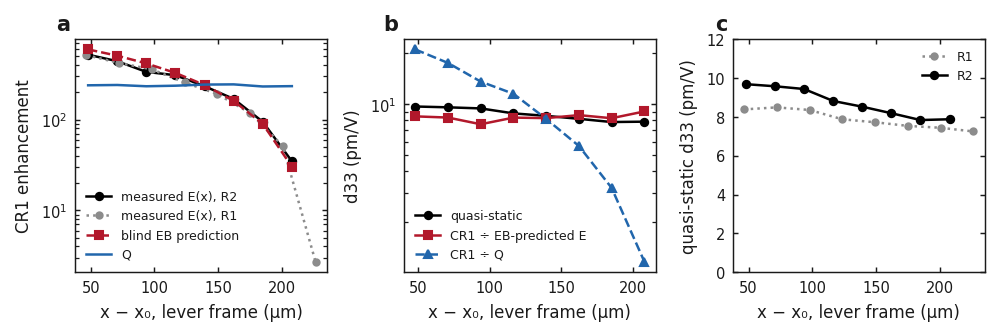

In [5]:
eb = F.load("scmpitB_r2_eb_fit")
assert np.allclose(eb['X'], t2.x_um), "EB fit positions differ from the survey"
interior = t2.x_um < t2.x_um.max()                       # free end excluded, as in the manuscript
ratio = (eb['E_meas'] / eb['E_mod'])[interior]
print(f"blind EB: E_meas/E_mod over interior positions {ratio.min():.2f}-{ratio.max():.2f} "
      f"(sd {100*ratio.std()/ratio.mean():.0f} %); fitted L = {float(eb['L']):.1f} um")
print(f"measured E range {t2.E.min():.1f}-{t2.E.max():.1f}; Q = {t2.Q.mean():.0f} +- {t2.Q.std():.0f}")

fig, axs = fp.figure("double", aspect=0.34, ncols=3)
ax = axs[0]
ax.semilogy(t2.x_lever_um, t2.E, 'o-', color=fp.C['meas'], ms=3.5, label='measured E(x), R2')
ax.semilogy(t1.x_lever_um, t1.E, 'o:', color='0.55', ms=3, label='measured E(x), R1')
ax.semilogy(t2.x_lever_um, eb['E_mod'], 's--', color=fp.C['ebgp'], ms=3.5, label='blind EB prediction')
ax.semilogy(t2.x_lever_um, t2.Q, '-', color=fp.C['gp'], label='Q')
ax.set_xlabel("x − x₀, lever frame (µm)"); ax.set_ylabel("CR1 enhancement"); ax.legend(fontsize=6)
fp.panel_label(ax, "a")

ax = axs[1]
d_eb = domains.d33_from_enhancement(t2, eb['E_mod'], VAC)
ax.plot(t2.x_lever_um, t2.d33_qs, 'o-', color=fp.C['meas'], ms=3.5, label='quasi-static')
ax.plot(t2.x_lever_um, d_eb, 's-', color=fp.C['ebgp'], ms=3.5, label='CR1 ÷ EB-predicted E')
ax.plot(t2.x_lever_um, t2.d33_cr_over_Q, '^--', color=fp.C['gp'], ms=3.5, label='CR1 ÷ Q')
ax.set_yscale('log'); ax.set_xlabel("x − x₀, lever frame (µm)"); ax.set_ylabel("d33 (pm/V)")
ax.legend(fontsize=6); fp.panel_label(ax, "b")

ax = axs[2]
ax.plot(t1.x_lever_um, t1.d33_qs, 'o:', color='0.55', ms=3, label='R1')
ax.plot(t2.x_lever_um, t2.d33_qs, 'o-', color=fp.C['meas'], ms=3.5, label='R2')
ax.set_xlabel("x − x₀, lever frame (µm)"); ax.set_ylabel("quasi-static d33 (pm/V)")
ax.set_ylim(0, 12); ax.legend(fontsize=6); fp.panel_label(ax, "c")
fig.tight_layout(); fp.save(fig, "06_E_vs_Q_d33")

summary = pd.DataFrame({
    "route": ["quasi-static, per-position InvOLS", "CR1 / EB-predicted E (per-position InvOLS)",
              "CR1 / Q (the usual shortcut)"],
    "median_pm_per_V": [np.median(t2.d33_qs[interior]), np.median(d_eb[interior]),
                        np.median(t2.d33_cr_over_Q[interior])],
    "spread_x": [t2.d33_qs[interior].max()/t2.d33_qs[interior].min(),
                 d_eb[interior].max()/d_eb[interior].min(),
                 t2.d33_cr_over_Q[interior].max()/t2.d33_cr_over_Q[interior].min()]})
summary.round(3)

**Lever frame.** With positions measured from x₀(t), R1 and R2 E(x) fall on one curve even though
the contact stiffened between runs (k*/k 480 → 744, notebook 05a). In the fixed 6.1 µm frame the
two runs were offset by ~18 µm.

## Bias-resolved mode maps: piezoresponse vs electrostatic channel per position and frequency
The same two-domain fit applied at every frequency bin gives |P|(x, f) (flips with domain)
and |b|(x, f) (does not). Their ratio shows where along the lever, and at which mode, the
electrostatic force competes with the piezoresponse.

[PosixPath('/home/claude/work/paper_analysis/figures/06_bias_resolved_maps.png'),
 PosixPath('/home/claude/work/paper_analysis/figures/06_bias_resolved_maps.pdf')]

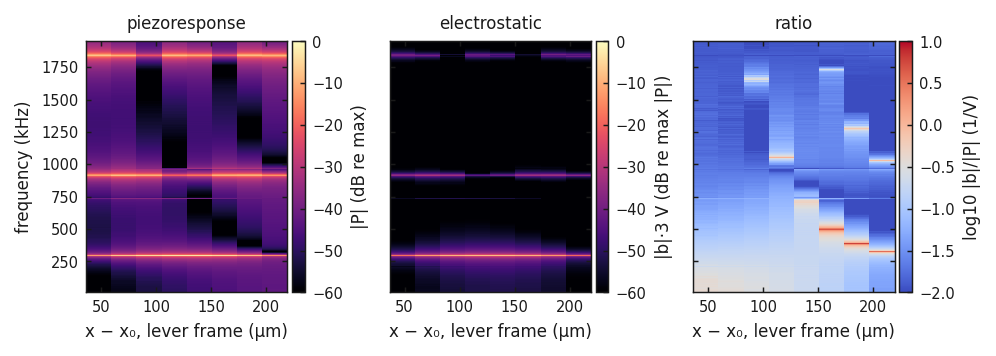

In [6]:
s = runs['r2']['series']
dec = domains.decompose_series(s, band=(10e3, 1950e3))
fq = dec['freq_Hz']
# smooth over ~1 kHz so single-bin noise does not dominate the log maps
k = max(1, int(round(1e3 / np.median(np.diff(fq)))))
sm = lambda A: np.apply_along_axis(lambda r: np.convolve(r, np.ones(k)/k, 'same'), 1, A)
Pm, bm = sm(np.abs(dec['P'])), sm(np.abs(dec['b']))
fig, axs = plt.subplots(1, 3, figsize=(fp.WIDTH_IN['double'], 2.4), sharey=True)
for ax, A, lab, vr in ((axs[0], Pm, '|P| (dB re max)', (-60, 0)),
                       (axs[1], bm * 3, '|b|·3 V (dB re max |P|)', (-60, 0))):
    im = ax.pcolormesh(t2.x_lever_um, fq/1e3, (20*np.log10(np.maximum(A, 1e-30)/Pm.max())).T,
                       cmap=fp.MAP_CMAP, vmin=vr[0], vmax=vr[1], shading='nearest', rasterized=True)
    plt.colorbar(im, ax=ax, label=lab, pad=0.02)
im = axs[2].pcolormesh(t2.x_lever_um, fq/1e3, np.log10(np.maximum(bm, 1e-30)/np.maximum(Pm, 1e-30)).T,
                       cmap=fp.ERR_CMAP, vmin=-2, vmax=1, shading='nearest', rasterized=True)
plt.colorbar(im, ax=axs[2], label='log10 |b|/|P| (1/V)', pad=0.02)
for ax in axs:
    ax.set_xlabel("x − x₀, lever frame (µm)")
axs[0].set_ylabel("frequency (kHz)")
axs[0].set_title("piezoresponse"); axs[1].set_title("electrostatic"); axs[2].set_title("ratio")
fig.tight_layout(); fp.save(fig, "06_bias_resolved_maps")

## Contact potential and model checks along the lever (R1 vs R2)

,run,vcpd_qs_mean,ratio_cr1_mean,d33_qs_median,Q_mean
0,R1,0.888,0.213,7.789,216.722
1,R2,1.076,0.190,8.659,238.403


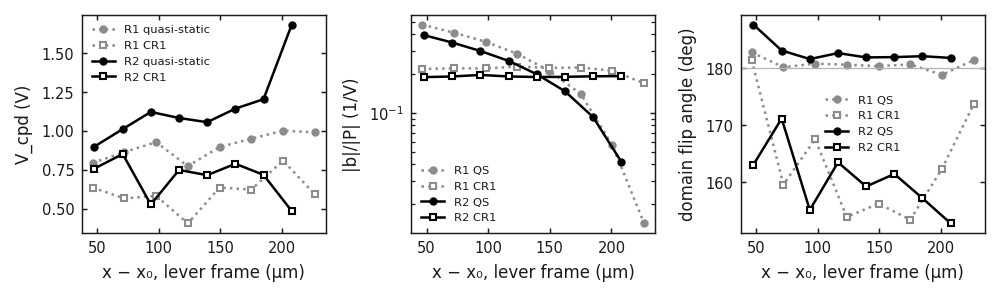

In [7]:
fig, axs = fp.figure("double", aspect=0.3, ncols=3)
for tag, t, sty in (("R1", t1, 'o:'), ("R2", t2, 'o-')):
    c = '0.55' if tag == 'R1' else fp.C['meas']
    axs[0].plot(t.x_lever_um, t.vcpd_qs, sty, color=c, ms=3, label=f'{tag} quasi-static')
    axs[0].plot(t.x_lever_um, t.vcpd_cr, sty.replace('o', 's'), color=c, ms=3, mfc='w', label=f'{tag} CR1')
    axs[1].plot(t.x_lever_um, t.ratio_qs, sty, color=c, ms=3, label=f'{tag} QS')
    axs[1].plot(t.x_lever_um, t.ratio_cr, sty.replace('o', 's'), color=c, ms=3, mfc='w', label=f'{tag} CR1')
    axs[2].plot(t.x_lever_um, t.flip_qs, sty, color=c, ms=3, label=f'{tag} QS')
    axs[2].plot(t.x_lever_um, t.flip_cr, sty.replace('o', 's'), color=c, ms=3, mfc='w', label=f'{tag} CR1')
axs[0].set_ylabel("V_cpd (V)"); axs[1].set_ylabel("|b|/|P| (1/V)"); axs[1].set_yscale('log')
axs[2].set_ylabel("domain flip angle (deg)"); axs[2].axhline(180, color='0.7', lw=0.6)
for ax in axs:
    ax.set_xlabel("x − x₀, lever frame (µm)"); ax.legend(fontsize=5.5)
fig.tight_layout(); fp.save(fig, "06_vcpd_checks")
pd.DataFrame({"run": ["R1", "R2"],
              "vcpd_qs_mean": [t1.vcpd_qs[:-1].mean(), t2.vcpd_qs[:-1].mean()],
              "ratio_cr1_mean": [t1.ratio_cr.mean(), t2.ratio_cr.mean()],
              "d33_qs_median": [np.median(t1.d33_qs), np.median(t2.d33_qs)],
              "Q_mean": [t1.Q.mean(), t2.Q.mean()]}).round(3)

**Reading the checks.** QS flip angles sit at 181–188° and |b|/|P| at CR1 is flat along the
lever (~0.19 /V in R2), so the two-domain model holds. The CR1 flip is further from 180° than
the QS flip; the V_cpd reported in the paper comes from the QS channel and the image
extrapolation, and the free-end QS V_cpd is poorly determined because b → 0 there.

In [8]:
results.save("fig6_transfer_function",
             dict(E_min=t2.E.min(), E_max=t2.E.max(), Q_mean=t2.Q.mean(), Q_sd=t2.Q.std(),
                  blind_eb_ratio_min=ratio.min(), blind_eb_ratio_max=ratio.max(),
                  d33_qs_median_interior=float(np.median(t2.d33_qs[interior])),
                  d33_cr_eb_median_interior=float(np.median(d_eb[interior])),
                  d33_cr_over_Q_median_interior=float(np.median(t2.d33_cr_over_Q[interior])),
                  d33_cr_over_Q_spread=float(summary.spread_x[2]),
                  r1_d33_qs_median=float(np.median(t1.d33_qs))),
             table=t2.assign(E_eb=eb['E_mod'], d33_cr_eb=d_eb))

PosixPath('/home/claude/work/paper_analysis/results/fig6_transfer_function.json')